# Day 8 — Understanding the F1 Dataset

Load and inspect all F1 dataset files, document what each
represents, check data quality, and observe with a open questions.


## 1. Setup

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from models.utils import (
    load_all_csvs,
    profile_dataframe,
    summarize_all,
    missing_value_report,
    missing_value_report_all,
    duplicate_report,
    numeric_outlier_scan,
    check_referential_integrity,
)

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
sns.set_style("whitegrid")

DATA_DIR = "../dataset"


## 2. Load all dataset files

One function call loads everything into a dict of DataFrames, keyed by filename. This replaces 14 separate `pd.read_csv(...)` calls.

***Note***: the Ergast/F1 uses the string `\N` for SQL NULL — `load_all_csvs()` tells pandas to treat that as a missing value, so `.isna()` works correctly everywhere.

In [2]:
dfs = load_all_csvs(DATA_DIR)
print(f"Loaded {len(dfs)} files:")
for name in dfs:
    print(f"  - {name:25s} {dfs[name].shape}")


Loaded 14 files:
  - circuits                  (77, 9)
  - constructor_results       (12625, 5)
  - constructor_standings     (13391, 7)
  - constructors              (212, 5)
  - driver_standings          (34863, 7)
  - drivers                   (861, 9)
  - lap_times                 (589081, 6)
  - pit_stops                 (11371, 7)
  - qualifying                (10494, 9)
  - races                     (1125, 18)
  - results                   (26759, 18)
  - seasons                   (75, 2)
  - sprint_results            (360, 16)
  - status                    (139, 2)


## 3. What each file represents

| File | Each row represents | Key columns | Role |
|---|---|---|---|
| `seasons` | one F1 season | `year` | Reference — list of years |
| `races` | one Grand Prix event | `raceId`, `year`, `circuitId` | **Hub table** — almost everything joins through this |
| `circuits` | one track | `circuitId` | Reference — where races happen |
| `drivers` | one driver | `driverId` | Reference — who races |
| `constructors` | one team | `constructorId` | Reference — who they race for |
| `status` | one finish/DNF reason | `statusId` | Reference — lookup for `results.statusId` |
| `results` | one driver's result in one race | `raceId`+`driverId` | **Most important fact table** — final classification, points, time |
| `qualifying` | one driver's qualifying result | `raceId`+`driverId` | Q1/Q2/Q3 times, grid origin |
| `sprint_results` | one driver's sprint race result | `raceId`+`driverId` | Same shape as `results`, sprint format only (2021+) |
| `driver_standings` | a driver's cumulative points after a race | `raceId`+`driverId` | Championship standings snapshot |
| `constructor_standings` | a team's cumulative points after a race | `raceId`+`constructorId` | Championship standings snapshot |
| `constructor_results` | a team's points in one race | `raceId`+`constructorId` | Team-level points (pre-2010 had separate scoring) |
| `lap_times` | one driver's time on one lap | `raceId`+`driverId`+`lap` | **Largest file** — granular timing data |
| `pit_stops` | one pit stop event | `raceId`+`driverId`+`stop` | Pit lane timing |


## 4. Which files appear most important

Ranked by how central they are to answering typical F1 questions ("who won," "how did points develop," "who drove for whom"):

1. **`results`** — The most important fact table. Has the final classification, points, status, and timing for every driver in every race since 1950.
2. **`races`** — Needed to translate `raceId` into a year, round, and circuit for almost any other table.
3. **`drivers`** / **`constructors`** — Needed to turn IDs into names.
4. **`driver_standings`** / **`constructor_standings`** — Needed for answering the "championship at this point in the season" questions, which `results` alone cannot answer (it only has per-race points, not cumulative).
5. **`lap_times`** and **`pit_stops`** — Important for race-strategy / performance analysis, but not needed for season-level questions.
6. **`qualifying`**, **`sprint_results`**, **`constructor_results`** — Useful for specific questions (grid position, sprint) but not central to most analysis(supplemetary).
7. **`circuits`**, **`status`**, **`seasons`** — Small reference/lookup tables. Useful but low-stakes since they rarely have data quality issues at this size.


## 5. Data quality — summary across all 14 files

In [3]:
summary = summarize_all(dfs)
summary


,file,rows,columns,duplicate_rows,missing_cells,missing_%,cols_with_missing
0,lap_times,589081,6,0,0,0.00,0
1,driver_standings,34863,7,0,0,0.00,0
2,results,26759,18,0,122887,25.51,8
3,constructor_standings,13391,7,0,0,0.00,0
4,constructor_results,12625,5,0,12608,19.97,1
5,pit_stops,11371,7,0,0,0.00,0
6,qualifying,10494,9,0,11668,12.35,3
7,races,1125,18,0,11349,56.04,11
8,drivers,861,9,0,1559,20.12,2
9,sprint_results,360,16,0,73,1.27,5


**Observation:** no file has full-row duplicates. 

`races` has the highest missing-cell percentage (56%) but this is structural, not a data quality problem(see below).


### 5.1 Missing values 

In [4]:
missing_all = missing_value_report_all(dfs)
missing_all


/Users/phuwasinkriangdechachai/Desktop/Internship/Day_9/models/utils.py:73: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat(reports, ignore_index=True)


,file,column,missing_count,missing_pct
0,constructor_results,status,12608,99.87
1,drivers,number,802,93.15
2,drivers,code,757,87.92
3,qualifying,q3,6865,65.42
4,qualifying,q2,4647,44.28
5,qualifying,q1,156,1.49
6,races,sprint_time,1110,98.67
7,races,sprint_date,1107,98.40
8,races,fp3_time,1072,95.29
9,races,fp1_time,1057,93.96


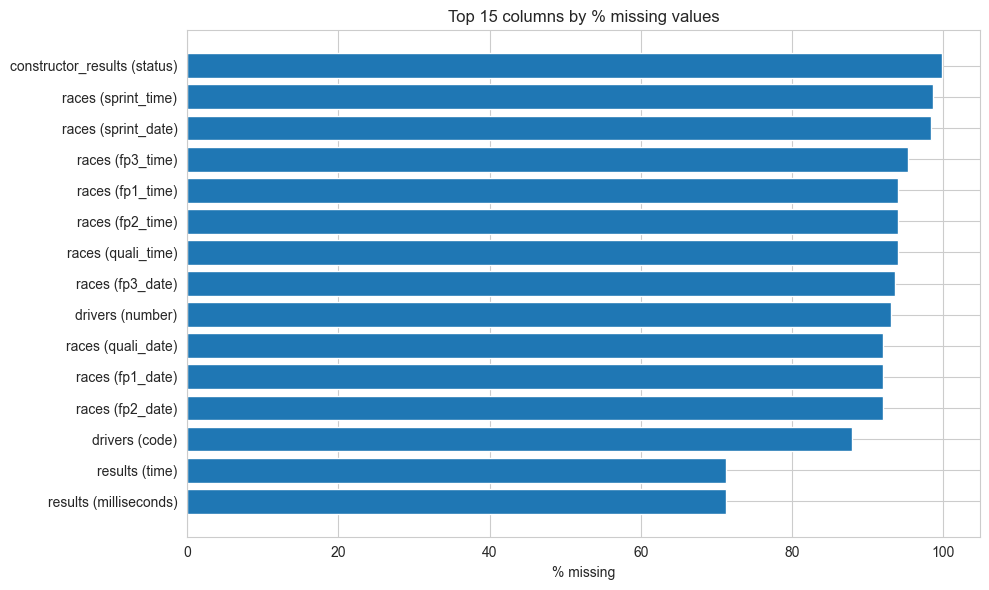

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
top_missing = missing_all.sort_values("missing_pct", ascending=True).tail(15)
ax.barh(top_missing["file"] + " (" + top_missing["column"] + ")", top_missing["missing_pct"])
ax.set_xlabel("% missing")
ax.set_title("Top 15 columns by % missing values")

plt.tight_layout()
plt.savefig("visualization/missing_values_chart.png", dpi=120)
plt.show()


### Analysis
**Why `races` has so much missing data?:** the `fp1_date`, `fp1_time`, `fp2_*`, `fp3_*`, `quali_date/time`, and `sprint_date/time` columns are only populated from the 2021 season onward — every single race before 2021 has `NaN` in all of these columns, with no exceptions (verified below).

I've done some research about why — it's documented directly by Ergast, the organization that maintains this dataset. Their public changelog(https://ergast1.rssing.com/chan-6123272/all_p2.html) has two entries that explain exactly what happened:

1.  > **"Enhanced Schedule Data" — March 13, 2022**     
    > "This year the race schedule will include information about all the race sessions e.g. FP 1-3, qualifying and sprint races."

2.  > **"Sprint Qualifying Results" — March 3, 2022**  
    > "Sprint qualifying results will be properly supported during the 2022 season and data for the sprint races in 2021 has been added retrospectively."

In other words: Free Practice and Qualifying sessions obviously *happened* in every season back to 1950 — but Ergast only started **recording session date/time data** for them starting around the 2021 season. The missing values for 1950–2020 reflect a gap in what the data source chose to track, not a gap in F1 history itself.

Similarly, `drivers.number` and `drivers.code` are mostly missing for older drivers — permanent car numbers (`number`) were introduced as an official F1 rule starting in **2014** (also documented in the same Ergast changelog, "Permanent Driver Numbers," March 7, 2014), and 3-letter driver codes (`code`) follow the same modern-era convention.

For the `results`: ~25% missing across `time`, `milliseconds`, `fastestLap`, `rank`, `fastestLapTime`, `fastestLapSpeed`. This is mostly because a driver who didn't finish (DNF) or wasn't classified has no finish time or fastest-lap data to report — i.e. missingness correlates with `statusId != Finished`, which we verify below.


In [6]:
fp_cols = ["fp1_date", "fp2_date", "fp3_date", "quali_date", "sprint_date"]
races = dfs["races"]

for col in fp_cols:
    pre_2021 = races[races["year"] < 2021][col].notna().sum()
    post_2021 = races[races["year"] >= 2021][col].notna().sum()
    print(f"{col:15s} populated rows before 2021: {pre_2021:4d}   |   from 2021 onward: {post_2021:4d}")

fp1_date        populated rows before 2021:    0   |   from 2021 onward:   90
fp2_date        populated rows before 2021:    0   |   from 2021 onward:   90
fp3_date        populated rows before 2021:    0   |   from 2021 onward:   72
quali_date      populated rows before 2021:    0   |   from 2021 onward:   90
sprint_date     populated rows before 2021:    0   |   from 2021 onward:   18


In [7]:
results = dfs["results"]
status = dfs["status"]

merged = results.merge(status, on="statusId")
finished = merged[merged["status"] == "Finished"]
not_finished = merged[merged["status"] != "Finished"]

print("Missing 'time' when Finished:    ", finished["time"].isna().mean().round(3))
print("Missing 'time' when NOT Finished:", not_finished["time"].isna().mean().round(3))


Missing 'time' when Finished:     0.0
Missing 'time' when NOT Finished: 1.0


### 5.2 Duplicate records — exact and key-based

In [8]:
checks = [
    ("circuits", ["circuitRef"]),
    ("constructors", ["constructorRef"]),
    ("drivers", ["driverRef"]),
    ("status", ["statusId"]),
    ("seasons", ["year"]),
    ("races", ["year", "round"]),
    ("results", ["raceId", "driverId"]),
    ("qualifying", ["raceId", "driverId"]),
    ("sprint_results", ["raceId", "driverId", "constructorId"]),
    ("driver_standings", ["raceId", "driverId"]),
    ("constructor_standings", ["raceId", "constructorId"]),
    ("constructor_results", ["raceId", "constructorId"]),
    ("lap_times", ["raceId", "driverId", "lap"]),
    ("pit_stops", ["raceId", "driverId", "stop"]),
]

dup_results = [duplicate_report(dfs[name], name, keys) for name, keys in checks]
dup_df = pd.DataFrame(dup_results)
dup_df


,file,full_row_duplicates,key_columns,key_duplicates
0,circuits,0,[circuitRef],0
1,constructors,0,[constructorRef],0
2,drivers,0,[driverRef],0
3,status,0,[statusId],0
4,seasons,0,[year],0
5,races,0,"[year, round]",0
6,results,0,"[raceId, driverId]",91
7,qualifying,0,"[raceId, driverId]",0
8,sprint_results,0,"[raceId, driverId, constructorId]",0
9,driver_standings,0,"[raceId, driverId]",0


**Observation:** All 14 tables are checked here, each against its own correct natural key. 13 of the 14 are completely clean. The one exception is `results`, it has 91 rows where `(raceId, driverId)`repeats.

In [ ]:
dupe_keys = results[results.duplicated(subset=["raceId", "driverId"], keep=False)]
dupe_keys[["resultId", "raceId", "driverId", "constructorId", "position", "positionText"]].sort_values(
    ["raceId", "driverId"]
).head(10)

,resultId,raceId,driverId,constructorId,position,positionText
13188,13189,540,229,54,NaN,F
13191,13192,540,229,57,NaN,F
17362,17363,717,373,172,7.0,7
24298,24304,717,373,172,NaN,R
17740,17741,733,465,172,NaN,W
17743,17744,733,465,97,NaN,W
17961,17962,742,475,102,NaN,D
17963,17964,742,475,172,NaN,R
18062,18063,745,418,172,NaN,R
24297,24303,745,418,172,11.0,11


In [ ]:
races = dfs["races"]
dupe_with_year = dupe_keys.merge(races[["raceId", "year"]], on="raceId")
dupe_with_year["year"].value_counts().sort_index() 

year
1950     8
1951     8
1952     6
1953    30
1954    33
1955    33
1956    24
1957    16
1958     6
1960     2
1961     4
1962     2
1964     2
1978     2
Name: count, dtype: int64

In [ ]:
dupe_with_year[dupe_with_year["year"] > 1970][["raceId", "year", "driverId", "constructorId", "positionText"]]


,raceId,year,driverId,constructorId,positionText
0,540,1978,229,54,F
1,540,1978,229,57,F


### Analysis: 
In every duplicated case, the same `driverId` appears twice for the same race, but under a **different `constructorId`**. (one driver, two team entries, same race.)

**Most of this (174 of the 176 rows) was in 1950-1964**, in this era a driver could be entered by two different teams for the same race, for
example, racing for their usual team, then also driving a second team's spare car later. As entry rules formalized over time, this practice disappeared, which is why duplicates stop showing up after 1964.

**There's one later exception worth a closer look: The 1978 exception**, two rows belong to driver **Harald Ertl** at the 1978 Italian Grand Prix
(https://en.wikipedia.org/wiki/1978_Italian_Grand_Prix). After I've checked in the Wikipedia's results table for that race: Ertl failed to pre-qualify driving for **ATS-Ford**, then also appear entered for **Ensign-Ford** in the same event. So this isn't the same 1950s "second team's car" pattern — it's a driver who changed teams mid-weekend, and both entries ended up recorded in `results.csv`.

### Remark:
At first, `(raceId, driverId)` looks like it should uniquely identify one row, "one driver in one race", but it doesn't, because of the 91 cases above. 

For an example, the 1978 exception, if I write code that groups or aggregates using only `raceId` and `driverId` — e.g. `results.groupby(["raceId", "driverId"])`, pandas sees `raceId=540, driverId=229` on *both* rows and treats them as **one group**, silently combining them into a single row. The two entries get merged together, and the fact that Ertl was entered for 2 teams disappears from the result — with no error, even though they represent two separate team entries.

Unless, use `resultId` as the unique key (it's guaranteed unique for every row), or use `(raceId, driverId, constructorId)` together if
you need a natural-key combination instead.



#### 5.2.1 Deeper analysis for `results`

In [ ]:
check_result = [
    ("results", ["raceId", "driverId", "constructorId"]),
]

dup_results = [duplicate_report(dfs[name], name, keys) for name, keys in check_result]
dup_df = pd.DataFrame(dup_results)
dup_df


,file,full_row_duplicates,key_columns,key_duplicates
0,results,0,"[raceId, driverId, constructorId]",74


Even with `constructorId` included in the key, **74 driver-race-team combinations (145 rows) still repeat**. That's a stronger finding than "same driver, different team" — it means the same driver, on the same team, in the same race, appears twice. Worth investigating directly.


In [ ]:
dupe_keys = results[results.duplicated(subset=["raceId", "driverId", "constructorId"], keep=False)]
dupe_keys[["resultId", "raceId", "driverId", "constructorId", "number", "laps", "position", "positionText", "statusId"]].sort_values(
    ["raceId", "driverId"]
).head(10)


,resultId,raceId,driverId,constructorId,number,laps,position,positionText,statusId
17362,17363,717,373,172,1.0,102,7.0,7,60
24298,24304,717,373,172,2.0,54,NaN,R,98
18062,18063,745,418,172,22.0,23,NaN,R,6
24297,24303,745,418,172,21.0,92,11.0,11,18
18082,18083,746,475,170,36.0,40,NaN,R,22
20295,22372,746,475,170,38.0,80,3.0,3,1
18611,18612,770,479,118,10.0,16,NaN,R,5
20293,20296,770,479,118,12.0,35,NaN,R,5
18693,18694,774,566,105,34.0,1,NaN,R,64
20294,20297,774,566,105,32.0,69,4.0,4,11


In [ ]:
races = dfs["races"]
dupe_with_year = dupe_keys.merge(races[["raceId", "year"]], on="raceId")
dupe_with_year["year"].value_counts().sort_index()


year
1950     6
1951     8
1952     6
1953    20
1954    24
1955    33
1956    22
1957    16
1958     4
1960     2
1961     2
1964     2
Name: count, dtype: int64

##### For each duplicated (raceId, driverId, constructorId) group, does the car 'number' differ between the two rows? 
That would mean the same driver appeared in two different physical cars for the same team.


In [ ]:
groups = dupe_keys.groupby(["raceId", "driverId", "constructorId"])
diff_number = sum(1 for _, g in groups if g["number"].nunique() > 1)
same_number = sum(1 for _, g in groups if g["number"].nunique() <= 1)
print(f"Groups where car 'number' DIFFERS between the two rows: {diff_number}")
print(f"Groups where car 'number' is the SAME (or missing):     {same_number}")


Groups where car 'number' DIFFERS between the two rows: 71
Groups where car 'number' is the SAME (or missing):     0


### Analysis:
The car `number` differs in every comparable case (71 of 74 groups — the other 3 have a missing `number` and can't be compared). That confirms the hypothesis that: **the same driver appeared in two different physical cars for the same team, in the same race.**

For example — Jim Clark, race 717, both rows for constructor 172:

```
resultId  number  laps  positionText  statusId
17363     1       102   7             60   (Did not finish / classified)
24304     2       54    R             98   (Retired)
```

Same driver, same team, but **car #1** and **car #2** — two separate entries, most likely because Clark started the race in one car, it broke down, and he took over a teammate's car for the rest of the race. Both period got recorded as separate rows.

**All 74 cases fall in 1950-1964**: The same era as the driver/different-team duplicates investigated earlier and for the same underlying reason: F1's entry rules in this period allowed much more flexibility around which car a driver could be in, including switching cars mid-race. As entry rules formalized, this pattern disappears entirely after 1964.

### Remark:
Even `(raceId, driverId, constructorId)` — which already accounts for the driver/different-team case — **is still not a safe unique key** for `results`. These 74 cases share all three values and only differ by `number` (the car) and `resultId`.

**The only column guaranteed unique in `results` is `resultId`.** Any `groupby`, `merge`, or duplicate check on this table should use `resultId` directly, or include `number` alongside `(raceId, driverId, constructorId)` if a natural-key combination is required instead.


### 5.3 Referential Integrity(Orphaned foreign keys)

In [ ]:
fk_checks = [
    ("races", "circuitId", "circuits", "circuitId"),

    ("results", "raceId", "races", "raceId"),
    ("results", "driverId", "drivers", "driverId"),
    ("results", "constructorId", "constructors", "constructorId"),
    ("results", "statusId", "status", "statusId"),

    ("qualifying", "raceId", "races", "raceId"),
    ("qualifying", "driverId", "drivers", "driverId"),
    ("qualifying", "constructorId", "constructors", "constructorId"),

    ("sprint_results", "raceId", "races", "raceId"),
    ("sprint_results", "driverId", "drivers", "driverId"),
    ("sprint_results", "constructorId", "constructors", "constructorId"),
    ("sprint_results", "statusId", "status", "statusId"),

    ("driver_standings", "raceId", "races", "raceId"),
    ("driver_standings", "driverId", "drivers", "driverId"),

    ("constructor_standings", "raceId", "races", "raceId"),
    ("constructor_standings", "constructorId", "constructors", "constructorId"),

    ("constructor_results", "raceId", "races", "raceId"),
    ("constructor_results", "constructorId", "constructors", "constructorId"),

    ("lap_times", "raceId", "races", "raceId"),
    ("lap_times", "driverId", "drivers", "driverId"),

    ("pit_stops", "raceId", "races", "raceId"),
    ("pit_stops", "driverId", "drivers", "driverId"),
]

fk_results = [
    check_referential_integrity(dfs[c], ck, dfs[p], pk, c, p)
    for c, ck, p, pk in fk_checks
]
fk_df = pd.DataFrame(fk_results)
fk_df


,child_file,parent_file,key,orphaned_ids,sample_orphaned
0,races,circuits,circuitId,0,[]
1,results,races,raceId,0,[]
2,results,drivers,driverId,0,[]
3,results,constructors,constructorId,0,[]
4,results,status,statusId,0,[]
5,qualifying,races,raceId,0,[]
6,qualifying,drivers,driverId,0,[]
7,qualifying,constructors,constructorId,0,[]
8,sprint_results,races,raceId,0,[]
9,sprint_results,drivers,driverId,0,[]


### Analysis:
**Every foreign key relationship that exists in the dataset** — all 22 of them, derived directly from which ID columns are present in each of the 14 files (`seasons` and `status` have no outgoing foreign keys, so they only appear as parents here).
Every single check returns 0 orphaned IDs. Every `driverId`, `constructorId`, `raceId`, `circuitId`, and `statusId` referenced anywhere in the dataset exists in its parent table.


### 5.4 Unexpected / Suspicious value

Each file is checked with rules appropriate for its content: coordinate bounds, valid date ranges, positive-only counts, format patterns, and sentinel values that look numeric but encode a special meaning.

**Non-numeric codes in `positionText`** — this column mixes numeric finishing positions with single-letter codes for drivers who didn't finish normally:

| Code | Meaning | Example situation |
|---|---|---|
| `R` | Retired | Engine failure, accident, mechanical issue |
| `F` | Pit lane start | Driver started from pit lane instead of a numbered grid slot (always paired with `grid = 0`) |
| `W` | Withdrew | Driver withdrew before or during the event |
| `N` | Not classified | Completed less than 90% of race distance — no official position awarded |
| `D` | Disqualified | Car failed post-race technical inspection, or rules violation |
| `E` | Excluded | Excluded before or during the race |

***None of these codes are documented anywhere in the CSV files, correct interpretation requires either external knowledge of the Ergast schema or cross-referencing with `status.csv`. This is flagged here because when anyone encountering this column for the first time would have no way to know what `"F"` or `"N"` means without a data dictionary.


In [ ]:
import re

unexpected_findings = []

def flag(file, col, description, count):
    unexpected_findings.append({
        "file": file, "column": col,
        "description": description, "affected_rows": count
    })

# Circuits 
c = dfs["circuits"]
flag("circuits", "lat/lng", "out-of-range coordinates",
     len(c[(c.lat < -90)|(c.lat > 90)|(c.lng < -180)|(c.lng > 180)]))
flag("circuits", "alt", "negative altitude (below sea level — real, not an error)",
     len(c[c["alt"] < 0]))

# Drivers
d = dfs["drivers"].copy()
d["dob_dt"] = pd.to_datetime(d["dob"], errors="coerce")
flag("drivers", "dob", "born before 1900 (Indianapolis 500 invitees, pre-F1 era)",
     len(d[d["dob_dt"] < "1900-01-01"]))

# Results
res = dfs["results"]
flag("results", "grid", "grid=0: encodes pit-lane start, not a real grid slot",
     len(res[res["grid"] == 0]))
flag("results", "rank", "rank=0: fastest-lap rank not applicable (driver retired early)",
     len(res[res["rank"] == 0]))
flag("results", "laps", "laps=0: driver failed to complete any lap",
     len(res[res["laps"] == 0]))
flag("results", "points", "points > 26 (possible only with fastest-lap bonus)",
     len(res[res["points"] > 26]))
flag("results", "fastestLap", "fastestLap > total laps raced (data inconsistency)",
     len(res[res["fastestLap"].notna() & res["laps"].notna() & (res["fastestLap"] > res["laps"])]))
non_numeric_pos = res[~res["positionText"].str.match(r"^\d+$", na=False)]
flag("results", "positionText", "non-numeric codes (R/F/W/N/D/E — see §5.4 note)",
     len(non_numeric_pos))

# Sprint_results
sr = dfs["sprint_results"]
flag("sprint_results", "grid", "grid=0: pit-lane start (same encoding as results)",
     len(sr[sr["grid"] == 0]))

# Qualifying
q = dfs["qualifying"]
weird_q1 = q[q["q1"].notna() & ~q["q1"].str.match(r"^\d+:\d+\.\d+$", na=False)]
flag("qualifying", "q1", "unexpected time format (not mm:ss.sss)", len(weird_q1))

# Lap_times
lt = dfs["lap_times"]
flag("lap_times", "milliseconds", "suspiciously long lap (>5 min = 300,000 ms — safety car?)",
     len(lt[lt["milliseconds"] > 300_000]))

# Pit_stops
ps = dfs["pit_stops"].copy()
ps["dur_num"] = pd.to_numeric(ps["duration"], errors="coerce")
flag("pit_stops", "duration", "pit stop > 60 s (extremely long — likely a drive-through penalty)",
     len(ps[ps["dur_num"] > 60]))
flag("pit_stops", "duration", "pit stop < 1.5 s (suspiciously fast — possible data entry error)",
     len(ps[ps["dur_num"] < 1.5]))

# constructor_results
cr = dfs["constructor_results"]
flag("constructor_results", "status", "only non-null value is 'D' (disqualified); 99.9% missing",
     cr["status"].notna().sum())

# driver_standings / constructor_standings 
ds = dfs["driver_standings"]
flag("driver_standings", "points", "negative cumulative points (disqualification deduction?)",
     len(ds[ds["points"] < 0]))

# seasons 
flag("seasons", "—", "no unexpected values detected", 0)

# status
st = dfs["status"]
flag("status", "status", "sensitive categories: Fatal accident / Injured",
     len(st[st["status"].isin(["Fatal accident","Injured","Eye injury"])]))

pd.DataFrame(unexpected_findings)


,file,column,description,affected_rows
0,circuits,lat/lng,out-of-range coordinates,0
1,circuits,alt,"negative altitude (below sea level — real, not...",1
2,drivers,dob,"born before 1900 (Indianapolis 500 invitees, p...",7
3,results,grid,"grid=0: encodes pit-lane start, not a real gri...",1638
4,results,rank,rank=0: fastest-lap rank not applicable (drive...,258
5,results,laps,laps=0: driver failed to complete any lap,2532
6,results,points,points > 26 (possible only with fastest-lap bo...,3
7,results,fastestLap,fastestLap > total laps raced (data inconsiste...,12
8,results,positionText,non-numeric codes (R/F/W/N/D/E — see §5.4 note),10951
9,sprint_results,grid,grid=0: pit-lane start (same encoding as results),11


### Remark:

- `grid = 0` and `rank = 0` in `results` are **intentional sentinel values**, not data errors — they encode "pit-lane start" and "no fastest-lap rank" respectively. Confirmed by cross-checking `positionText`.

- `laps = 0` means the driver was classified but completed no laps(e.g. failed on the formation lap).

- `points > 26` are legitimate: the fastest-lap bonus point (awarded since 2019) can push totals above the 25-point maximum for a win.

- `fastestLap > laps` (12 rows) is a real inconsistency — a driver cannot set a fastest lap on a lap they didn't complete. Worth flagging for any analysis that uses `fastestLap`.

- Lap times > 300,000 ms (5 minutes) in `lap_times` likely reflect safety car periods, red flags, or laps driven partly in the pit lane — not impossible, but worth filtering if computing true lap times.

- `constructor_results.status` has only one non-null value ('D' = disqualified) across 12,625 rows — the column is effectively unused.


### 5.5 Inconsistent data

In [ ]:
inconsistencies = []

def issue(check, finding, affected):
    inconsistencies.append({"check": check, "finding": finding, "affected_rows": affected})

res   = dfs["results"]
ds    = dfs["driver_standings"]
lt    = dfs["lap_times"]
ps    = dfs["pit_stops"]
races = dfs["races"]
q     = dfs["qualifying"]
cs    = dfs["constructor_standings"]

# position and positionOrder should be equal
classified = res[res["position"].notna()].copy()
classified["position_int"] = classified["position"].astype(int)
mismatch_pos = classified[classified["position_int"] != classified["positionOrder"]]
issue("results: position vs positionOrder",
      "classified drivers where position != positionOrder (One driver was disqualified after the race, which changed the final race order)",
      len(mismatch_pos))

# Max lap number should not exceed results.laps 
res_laps = res[["raceId","driverId","laps"]].rename(columns={"laps":"laps_results"})
max_lap_lt = lt.groupby(["raceId","driverId"])["lap"].max().reset_index(name="max_lap")
lap_check = max_lap_lt.merge(res_laps, on=["raceId","driverId"], how="left")
issue("lap_times vs results.laps",
      "rows where max lap in lap_times > laps in results (extra lap records beyond classified laps)",
      len(lap_check[lap_check["max_lap"] > lap_check["laps_results"]]))

# pit lap should not exceed driver's total laps
ps_max_lap = ps.groupby(["raceId","driverId"])["lap"].max().reset_index(name="last_pit_lap")
pit_check = ps_max_lap.merge(res_laps, on=["raceId","driverId"], how="left")
issue("pit_stops: pit lap vs results.laps",
      "rows where last pit lap > total laps (pit stops occurred after classified finish?)",
      len(pit_check[pit_check["last_pit_lap"] > pit_check["laps_results"]]))

# results.fastestLap should not exceed results.laps for same row
fl_check = res[res["fastestLap"].notna() & res["laps"].notna()]
issue("results: fastestLap vs laps",
      "rows where fastestLap lap number > total laps raced (impossible — data inconsistency)",
      len(fl_check[fl_check["fastestLap"] > fl_check["laps"]]))

# Pole position (qualifying=1) should start on grid 1 in results
pole = q[q["position"] == 1][["raceId","driverId"]]
pole_grid = pole.merge(res[["raceId","driverId","grid"]], on=["raceId","driverId"], how="left")
issue("qualifying pos=1 vs results grid=1",
      "races where pole-sitter did not start from grid 1 (penalties or pit-lane starts)",
      len(pole_grid[pole_grid["grid"] != 1]))

# driver_standings.positionText should equal numeric position
ds_num = ds[ds["positionText"].str.match(r"^\d+$", na=False)].copy()
ds_num["pt_int"] = ds_num["positionText"].astype(int)
issue("driver_standings: position vs positionText",
      "rows where position != positionText (should always match for numeric standings)",
      len(ds_num[ds_num["position"] != ds_num["pt_int"]]))

# constructor_standings positionText vs position
cs_num = cs[cs["positionText"].str.match(r"^\d+$", na=False)].copy()
cs_num["pt_int"] = cs_num["positionText"].astype(int)
issue("constructor_standings: position vs positionText",
      "rows where position != positionText",
      len(cs_num[cs_num["position"] != cs_num["pt_int"]]))

# Same Grand Prix name should not appear twice in the same year
dup_race_name = races[races.duplicated(subset=["year","name"], keep=False)]
issue("races: duplicate (year, name)",
      "races with the same name in the same year",
      len(dup_race_name))

pd.DataFrame(inconsistencies)


,check,finding,affected_rows
0,results: position vs positionOrder,classified drivers where position != positionO...,13
1,lap_times vs results.laps,rows where max lap in lap_times > laps in resu...,37
2,pit_stops: pit lap vs results.laps,rows where last pit lap > total laps (pit stop...,1
3,results: fastestLap vs laps,rows where fastestLap lap number > total laps ...,12
4,qualifying pos=1 vs results grid=1,races where pole-sitter did not start from gri...,14
5,driver_standings: position vs positionText,rows where position != positionText (should al...,0
6,constructor_standings: position vs positionText,rows where position != positionText,0
7,"races: duplicate (year, name)",races with the same name in the same year,0


### Analysis:
- **`position != positionOrder`** (13 rows, all in race 452): These were caused by a post-race disqualification. One driver was disqualified *after* the results were recoeded, causing other drivers' `position` values to shift up, but `positionOrder` was not updated to match. 

- **`lap_times` max lap > `results.laps`** (37 rows): In this cases, the maximum lap recorded in `lap_times` exceeds the lap count in `results`. This is most likely because additional laps, such as safety car laps or cool down laps after the end of the race, were recorded in `lap_times` but were not counted in the official classified lap total.

- **Last `pit_stop` lap > `results.laps`** (1 row): This scenario is impossible and is most likely caused by a data entry error.
For an example, one driver has a recorded pit stop on lap 29, while `results.laps` shows that the driver completed 0 laps. 

- **`fastestLap > laps`** (12 rows): A driver cannot have set their fastest lap on a lap that they didn't complete. Maybe caused by a timing correction applied to one field but not the other.

- **Pole-sitter not on grid 1** (14 races): This is a reasonable case rather than a data error. Although the driver qualified in first place, grid penalties (e.g., engine or gearbox penalties) were applied before the race, causing the driver to start further back on the grid.

- `driver_standings` and `constructor_standings` position vs positionText: **0 mismatches** — All are internally consistent. Numeric position matches its corresponding text representation

- **Duplicate Grand Prix names within the same season** (0 cases): No duplicate race names were found within the same year. Each Grand Prix appears only once per season, means consistent race naming.

## 6. Observations about the dataset

1. **`races` is the structural center of the entire dataset.** 8 of the other 13 files reference `raceId` directly. Almost any cross-file analysis starts by joining through `races`.

2. **Sprint races are very new and sparse.** `sprint_results` has only 360 rows vs. 26,759 in `results`, because sprint races started in 2021 and only happen at a few circuits each season. Any season-level comparison must account for this pre-2021 seasons have no sprint data at all.

3. **`seasons.csv` is disconnected from the rest.** It has no foreign key relationship with any other table and only contains `year` + a Wikipedia URL, information already available  in `races.year`. This file can be safely ignored for analysis.

4. **Most missing values are expected, not errors.**
   - Columns like `fp1_date`, `quali_date`, `sprint_date` in `races` are empty for all races before 2021, because Ergast only started recording session-level dates from 2021 onward (documented in their changelog).
   - `drivers.number` is 93% empty because permanent car numbers only became an official F1 rule in 2014.
   - Missing `time` and `milliseconds` in `results` almost always means the driver did not finish — not a data entry problem.

5. **`results` has a unique-key problem with two layers.**
   - Layer 1: `(raceId, driverId)` repeats in 176 rows — the same driver entered by two different teams in the same race (common in 1950–1964 when car-sharing was allowed).
   - Layer 2: Even adding `constructorId` still leaves 145 duplicate rows — same driver, same team, but two different cars (confirmed by different `number` values, e.g. car #1 broke down and the driver switched to car #2).
   - **Only** `resultId` is guaranteed unique in this table. Don't use `(raceId, driverId)` alone as a key.

6. **Races per season has changed from 7 to 24(3 times difference).** Comparing raw totals (points, wins, podiums) across eras is misleading without normalizing by the number of races in that season.

7. **Several result codes require external knowledge to decode.**
   The CSV files contain no documentation anywhere for:
   - `positionText` codes: `R` (Retired), `F` (Pit lane start), `W` (Withdrew), `N` (Not classified), `D` (Disqualified), `E` (Excluded)
   - `grid = 0` → pit lane start (not a real grid position)
   - `rank = 0` → fastest lap not applicable for this driver

8. **A post-race disqualification caused 13 rows of inconsistency.** In race 452, one driver was disqualified *after* results were recorded. Other drivers' `position` values were updated to shift up, but `positionOrder` was not — leaving 13 rows where the two columns mismatch.

9. **`fastestLap > laps` in 12 rows — impossible** — A driver cannot have their fastest lap on a lap number higher than their total laps raced. This is a real data inconsistency, likely caused by a timing correction applied to one field but not synced to the other.

10. **Ferrari, McLaren, and Mercedes dominate all-time race wins** Across 74 seasons, with Red Bull climbing rapidly in the 2010s-2020s. The dataset captures a structural concentration of success among a number of constructors. This could be used for any analysis that tries to isolate driver skill from a car performance.

11. **`constructor_results.status` is 99.9% empty** Only a little of non-null value exist in 12,625 rows, and all of them are `'D'` (disqualified). This column carries no useful information and can be dropped.

12. **`lap_times` includes outlier laps over 5 minutes.** Normal F1 lap times are roughly around 60–120 seconds. Laps recorded above 300,000 ms (5 minutes) are almost certainly safety car periods, red flags, or formation laps — not real race-pace data. Any performance analysis on `lap_times` should filter these out first.

13. **The dataset includes sensitive real-world events.** Three driver deaths are recorded in `status` as `Fatal accident` (Jochen Rindt 1970, Helmuth Koinigg 1974, Riccardo Paletti 1982). Any tooling or dashboards built on this data should handle these records respectfully rather than purely as "DNF reason #X."

## 7. Open questions for further analysis

1. **Does starting position actually cause a better finishing position, or do good cars just do both?** It looks like drivers who qualify near the front also tend to finish near the front, but that could be because they have a faster car, not because of where they started. Separating these two effects requires a more careful model, especially since rules like DRS (which makes overtaking easier) have changed how much
grid position actually matters over time.

2. **How much of a driver's results come from the car(constructor) vs their own skill?** A driver in a Ferrari starts every race with a big advantage over a driver in a backmarker team. To fairly compare driver ability, we need to strip out the team effect, which requires combining
data across `results`, `driver_standings`, and `constructor_standings` in a model that separates the two.

3. **Does pit stop timing actually change the final result, and has the best strategy shifted as tyre rules changed?** Stopping once vs twice or pitting early vs late, can gain or lose positions. But what works best has changed every time F1 changed its tyre regulations, and those regulation changes are not recorded anywhere in this dataset, so answering this requires `pit_stops` joined with `lap_times` and `results`, plus regulation history not present in any of these files.

4. **Are the 13 inconsistent rows in `position vs positionOrder` all from one single incident, or multiple?** All 13 affected rows are in race 452, but we cannot tell from the data alone whether they came from one disqualification or several. Answering this would require the original FIA stewards' decisions, which are not inclded in this dataset.

5. **Why do 12 rows have `fastestLap` higher than `laps` raced?** We know the inconsistency exists, but not why, is it always from the same era, the same data update, or random one-off errors? Confirming the cause would need cross-referencing against the original race timing sheets.

6. **Is the "experience curve" real for F1 drivers?** A driver's results in year 1 vs. year 3 might improve purely because they switched to a faster car, not because they got better. To find a real experience effect, the analysis needs to control for car performance, which makes this a multi-file, multi-season modelling problem.


## 8. Visualization

I'm just curioussss hehe

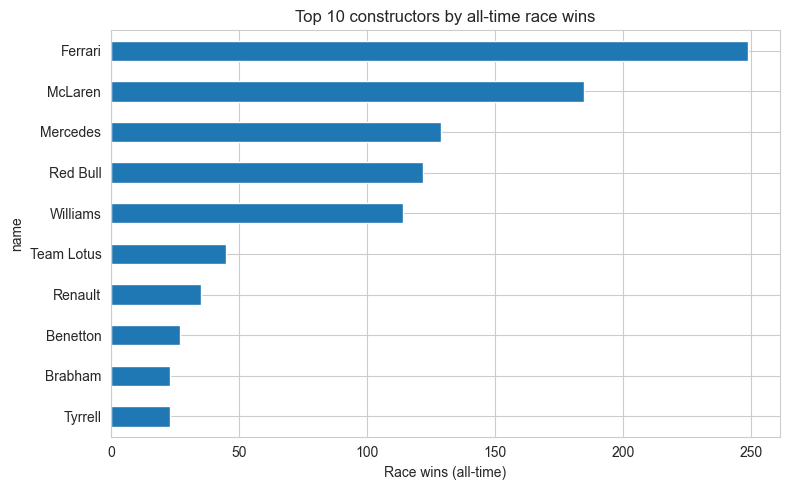

In [ ]:
constructors = dfs["constructors"]
wins = results[results["position"] == 1].merge(constructors[["constructorId", "name"]], on="constructorId")

fig, ax = plt.subplots(figsize=(8, 5))
wins["name"].value_counts().head(10).plot(kind="barh", ax=ax)
ax.invert_yaxis()
ax.set_xlabel("Race wins (all-time)")
ax.set_title("Top 10 constructors by all-time race wins")
plt.tight_layout()
plt.savefig("visualization/top_constructors_wins.png", dpi=120)
plt.show()


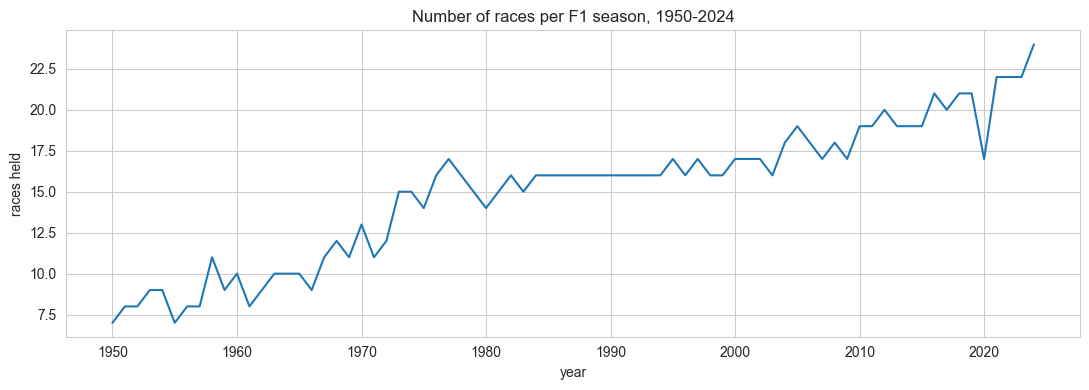

Fewest races in a season: 7 (year 1950)
Most races in a season:   24 (year 2024)


In [ ]:
races = dfs["races"]
races_per_year = races.groupby("year").size()

fig, ax = plt.subplots(figsize=(11, 4))
races_per_year.plot(ax=ax)
ax.set_ylabel("races held")
ax.set_title("Number of races per F1 season, 1950-2024")
plt.tight_layout()
plt.savefig("visualization/races_per_year.png", dpi=120)
plt.show()

print(f"Fewest races in a season: {races_per_year.min()} (year {races_per_year.idxmin()})")
print(f"Most races in a season:   {races_per_year.max()} (year {races_per_year.idxmax()})")

### Observation
- The Formula 1 calendar has expanded significantly since the championship began.
- Early seasons typically featured fewer than 10 races.
- Since the 2000s, the number of races has steadily increased, with recent seasons containing over 20 Grands Prix.
- This suggests that Formula 1 has become a much larger global championship compared to its early years.

# Day 9 — Exploring Formula 1 History

## 1. Prepare dataset

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
})
SAVE = "visualization/"
TEAL = "#009688"
ORANGE = "#FF6F00"
RED = "#D32F2F"
BLUE = "#1565C0"
GREY = "#757575"

DATA = "../dataset"
races            = pd.read_csv(f"{DATA}/races.csv",             na_values=["\\N"])
results          = pd.read_csv(f"{DATA}/results.csv",           na_values=["\\N"])
drivers          = pd.read_csv(f"{DATA}/drivers.csv",           na_values=["\\N"])
constructors     = pd.read_csv(f"{DATA}/constructors.csv",      na_values=["\\N"])
driver_standings = pd.read_csv(f"{DATA}/driver_standings.csv",  na_values=["\\N"])
circuits         = pd.read_csv(f"{DATA}/circuits.csv",          na_values=["\\N"])
status           = pd.read_csv(f"{DATA}/status.csv",            na_values=["\\N"])
pit_stops        = pd.read_csv(f"{DATA}/pit_stops.csv",         na_values=["\\N"])
lap_times        = pd.read_csv(f"{DATA}/lap_times.csv",         na_values=["\\N"])

drivers["name"] = drivers["forename"] + " " + drivers["surname"]

ERA_COLORS = {
    "1950s Pioneer":            "#795548",
    "1960s Growth":             "#FF8F00",
    "1970s Turbulent":          "#F57F17",
    "1980s Turbo":              "#558B2F",
    "1990s Modern":             "#00695C",
    "2000s Schumacher/Alonso":  "#1565C0",
    "2010s Hybrid":             "#4527A0",
    "2020s":                    "#B71C1C",
}
ERA_BOUNDS = {
    "1950s Pioneer":            (1950,1959),
    "1960s Growth":             (1960,1969),
    "1970s Turbulent":          (1970,1979),
    "1980s Turbo":              (1980,1989),
    "1990s Modern":             (1990,1999),
    "2000s Schumacher/Alonso":  (2000,2009),
    "2010s Hybrid":             (2010,2019),
    "2020s":                    (2020,2024),
}

print("All files loaded.")
print(f"Coverage: {races['year'].min()}–{races['year'].max()} "
      f"| {len(races)} races | {len(drivers)} drivers | {len(constructors)} constructors")


All files loaded.
Coverage: 1950–2024 | 1125 races | 861 drivers | 212 constructors


## 2. How has the scale of F1 changed over 74 seasons?

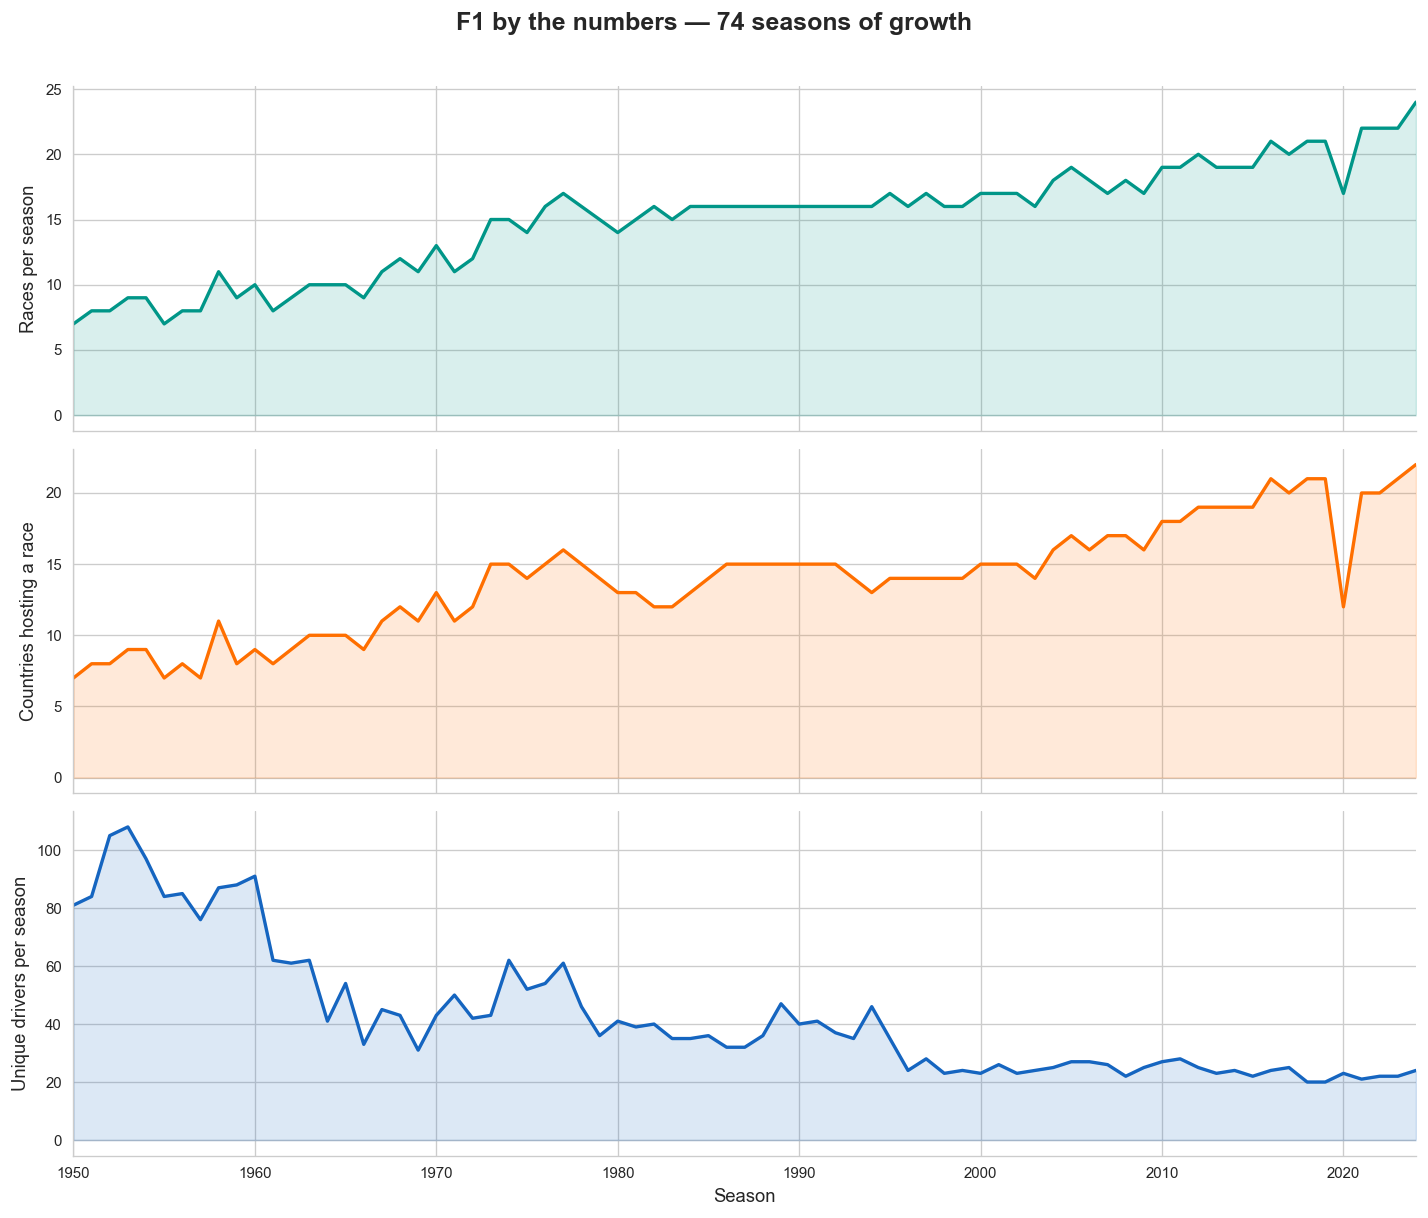

In [20]:
races_per_year = races.groupby("year").size().reset_index(name="n_races")
country_per_year = (
    races.merge(circuits[["circuitId","country"]], on="circuitId")
         .groupby("year")["country"].nunique()
         .reset_index(name="n_countries")
)

drivers_per_year = (
    results.merge(races[["raceId","year"]], on="raceId")
           .groupby("year")["driverId"].nunique()
           .reset_index(name="n_drivers")
)

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
fig.suptitle("F1 by the numbers — 74 seasons of growth", fontsize=15, fontweight="bold", y=1.01)

for ax, df, col, label, color in zip(
    axes,
    [races_per_year, country_per_year, drivers_per_year],
    ["n_races", "n_countries", "n_drivers"],
    ["Races per season", "Countries hosting a race", "Unique drivers per season"],
    [TEAL, ORANGE, BLUE],
):
    ax.fill_between(df["year"], df[col], alpha=0.15, color=color)
    ax.plot(df["year"], df[col], color=color, linewidth=2)
    ax.set_ylabel(label)
    ax.set_xlim(1950, 2024)

axes[-1].set_xlabel("Season")
plt.tight_layout()
plt.savefig(f"{SAVE}f1_growth.png", bbox_inches="tight")
plt.show()


## Observation:

### 2.1 Races per season
During the early years (1950-1960s), each season consisted of only 7-10 races. The races expanded throughout the 1970s and 1980s before stabalizing at around 16 races for more than a decade. From the 2000s onward, the number of races increased again, reaching over 20 Grands Prix per season in recent years.

From the trend, it reflects F1's transformation from a primarily European championship into a global sport. As the sport gained commercial popularity, new host countries joined the championship, and F1 management continued adding new venues to increase global audience. The drop around 2020 is likely associated with the COVID-19 pandemic, which multiple races were cancelled or postponed due to travel restrictions and public health measures. Despite the disruption, the calendar quickly recovered and reached a record number of races in the following seasons.

### 2.2 No. of host countries
The number of countries hosting F1 races has increased over time, although the growth has been changing more slowly than the increasing of the total number of races.

In the early decades, F1 events were concentrated mainly in Western Europe. As the championship expanded internationally, new host nations from Asia, North America, South America, the Middle East, and Oceania were gradually introduced.

The difference between this graph and the total number of races suggests that recent calendar expansion has not only come from adding new countries but also from hosting multiple races within the same country. Examples include Italy hosting both the Italian and Emilia-Romagna Grands Prix, Austria hosting consecutive races during the pandemic, and the US now hosting multiple Grands Prix in a single season. A temporary decline around 2020 is again consistent with the COVID-19 pandemic, when international travel restrictions reduced the geographical diversity of the championship before global expansion resumed.

### 2.3 Unique drivers per season
Unlike the previous two graphs, the number of unique drivers participating in each season shows a long-term downward trend.

During the 1950s and early 1960s, over 80 drivers often participated within a single season. This high number was largely due to many private entrants, local participants, and one-off race appearances, especially in European Grands Prix. At that time, F1 regulations were less standardized, making occasional participation more common.

Based on the modern F1 structure, where the grid consists of a limited number of full-time teams and drivers competing throughout the entire championship. From the 1970s onward, the number of unique drivers slowely declined and eventually stabilized at around 20–25 drivers per season. The decline does not indicate that F1 became less popular. Instead, it reflects the sport's professionalization. Modern F1 places greater emphasis on long-term contracts, higher financial barriers to entry, stricter licensing requirements, and consistent driver lineups, resulting in fewer one-off participants and a more stable championship.

## 3. Which drivers and teams dominated and in which eras?

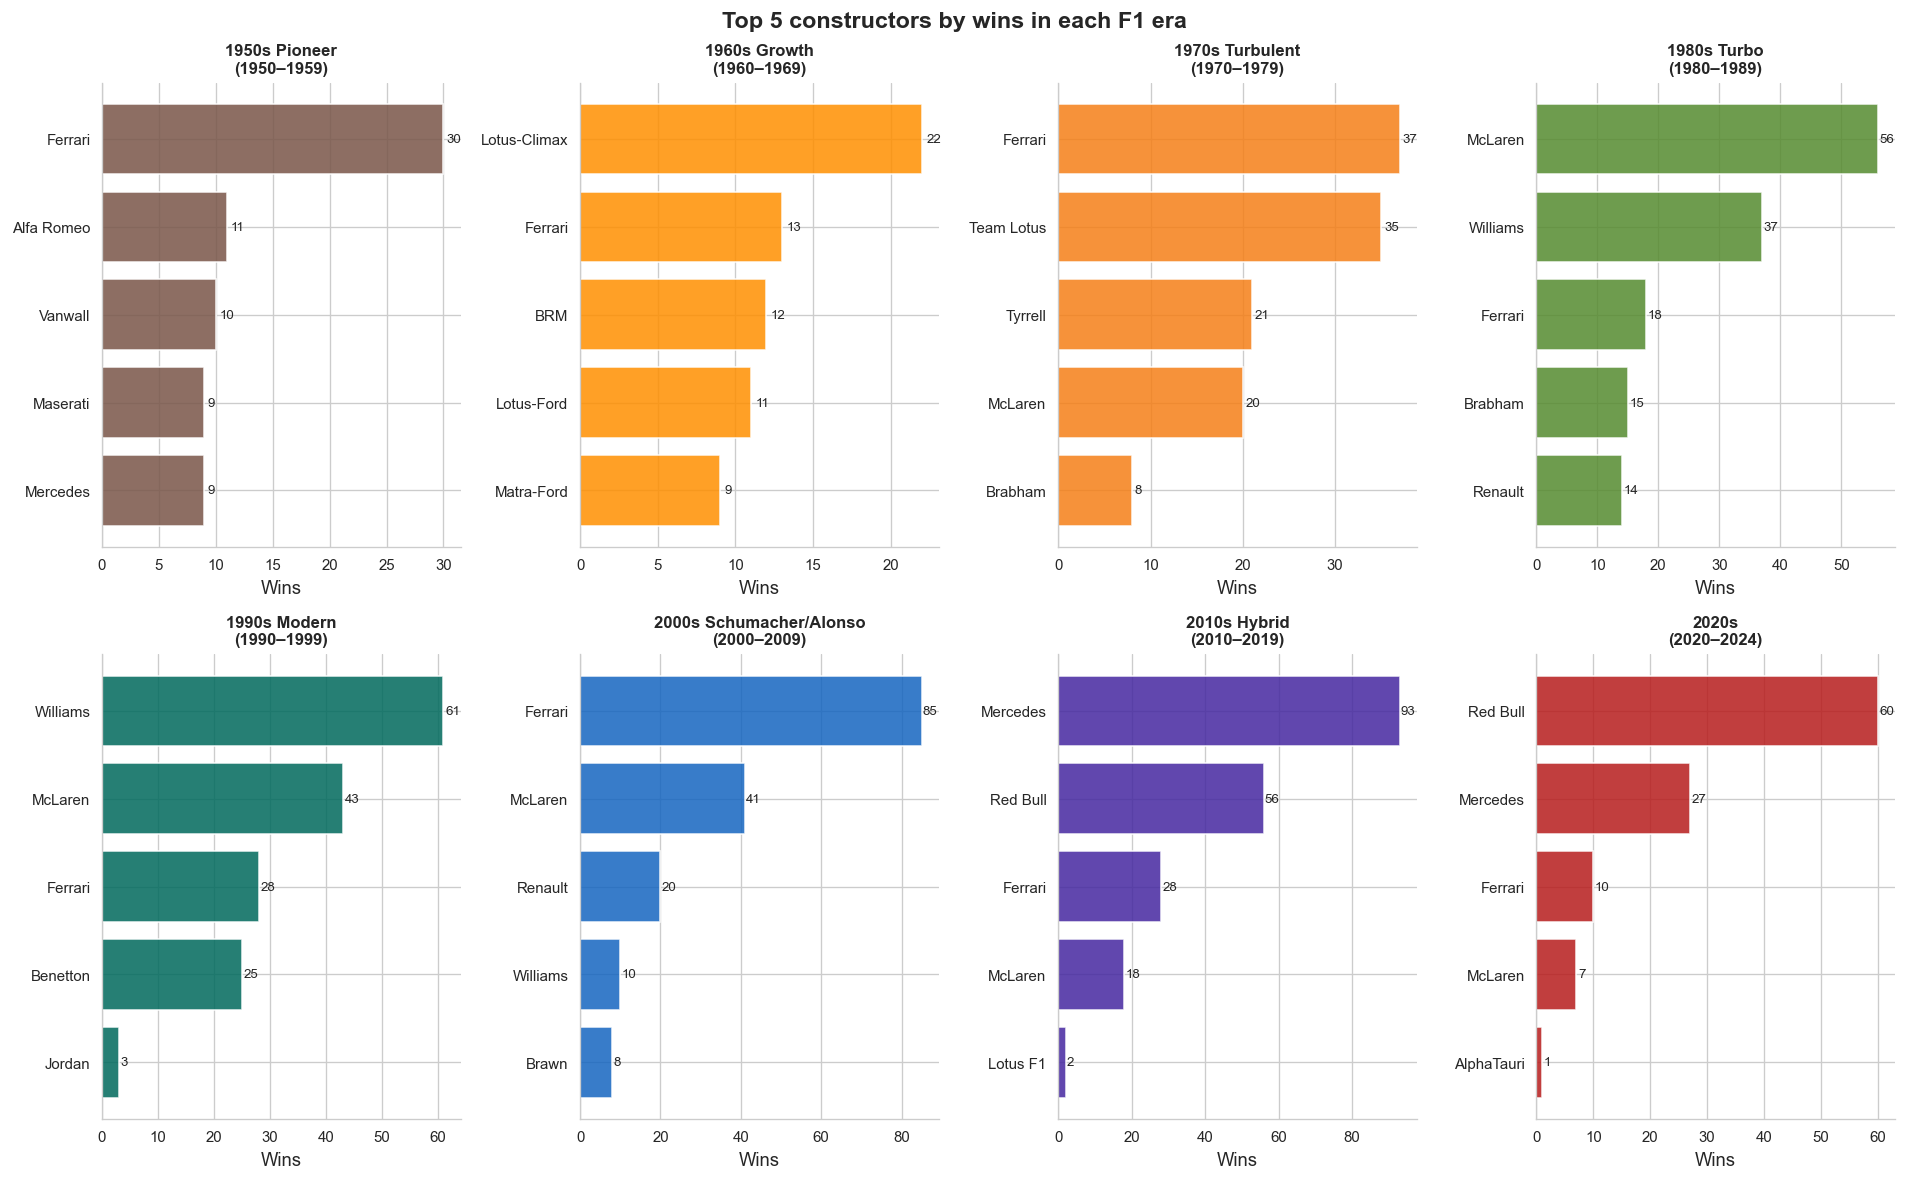

In [22]:
cwins = (
    results[results["position"] == 1]
    .merge(races[["raceId","year"]], on="raceId")
    .merge(constructors[["constructorId","name"]], on="constructorId")
)

era_con_wins = []
for era, (y1, y2) in ERA_BOUNDS.items():
    era_wins = cwins[(cwins["year"] >= y1) & (cwins["year"] <= y2)]
    top5 = era_wins["name"].value_counts().head(5).reset_index()
    top5.columns = ["constructor", "wins"]
    top5["era"] = era
    era_con_wins.append(top5)
era_con_df = pd.concat(era_con_wins, ignore_index=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 10))
fig.suptitle("Top 5 constructors by wins in each F1 era", fontsize=14, fontweight="bold")

for ax, (era, (y1, y2)) in zip(axes.flat, ERA_BOUNDS.items()):
    subset = era_con_df[era_con_df["era"] == era]
    bars = ax.barh(subset["constructor"][::-1], subset["wins"][::-1],
                   color=ERA_COLORS[era], alpha=0.85)
    ax.set_title(f"{era}\n({y1}–{y2})", fontsize=10, fontweight="bold")
    ax.set_xlabel("Wins")
    for bar, val in zip(bars, subset["wins"][::-1]):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(val), va="center", fontsize=8)

plt.tight_layout()
plt.savefig(f"{SAVE}era_constructor_dominance.png", bbox_inches="tight")
plt.show()


## Observation:
### 3.1 Each era has exactly 1 dominate team and it always changes
In every decade, one team controlled the top of the podium, but the identity of that team rotates completely. No team has ever stayed at the top across two consecutive eras. This happens because F1 changes its technical regulations roughly every 5–10 years, which effectively resets the competition and gives every team a new chance to find their advantage.

### 3.2 Dominance is becoming more concentrated over time
The top team's wins has rised consistently. In the 2020s, Red bull has wons **56.1%** of all races, more than every other team combined. The reason dominance has grown stronger over time is that modern F1 cars are far more complex and expensive to develop. When a team finds a technical advantage today, it is much harder for rivals to close the gap because doing so requires enormous resources and time. By the time a rival team catches up, the rules often change again.

### 3.3 Ferrari is the only team that appears in every panel
Ferrari appears in the top 5 in all eight eras, has won #1 in three of them (1950s, 1970s, 2000s), and finishing #2 or #3 in the other five. No other team comes close to this consistency. McLaren is the closest, appearing in six of eight eras, but has declined to just 7 wins so far in the 2020s. Ferrari's permanence is structural, it is the only team that has competed in every F1 season since 1950, giving them 74 years of accumulated knowledge and experience.

### 3.4 The 1960s was the most competitive era
The 1960s panel looks visually different from the rest, the bars are much more evenly spread, and the leading team(Lotus) has only a small advantage over the others. Six different constructors won 9–22 races each, and many entirely new teams(BRM, Matra-Ford) appeared as winners for the first time. This happened because regulations at the time were relatively simple, allowing small independent teams to build genuinely competitive cars without needing a massive budget. It was the last era where a small team could challenge for wins against the established names.



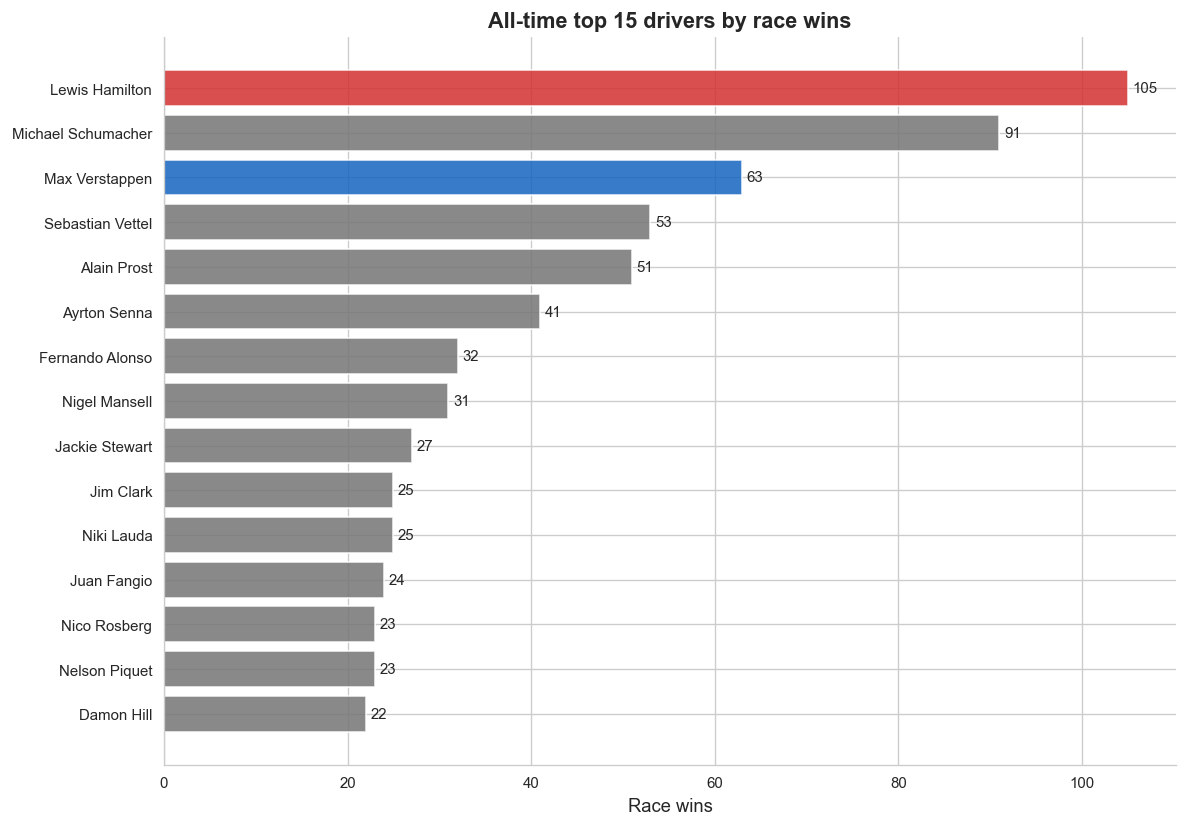

In [26]:
dwins = (
    results[results["position"] == 1]
    .merge(races[["raceId","year"]], on="raceId")
    .merge(drivers[["driverId","name"]], on="driverId")
)
top15_drivers = dwins["name"].value_counts().head(15).sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = [RED if n == "Lewis Hamilton"
          else BLUE if n == "Max Verstappen"
          else GREY for n in top15_drivers.index]
bars = ax.barh(top15_drivers.index, top15_drivers.values, color=colors, alpha=0.85)
for bar, val in zip(bars, top15_drivers.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va="center", fontsize=9)
ax.set_xlabel("Race wins")
ax.set_title("All-time top 15 drivers by race wins", fontweight="bold")
plt.tight_layout()
plt.savefig(f"{SAVE}alltime_driver_wins.png", bbox_inches="tight")
plt.show()


## Observation:
### 3.5 The top 3 
The chart splits into two tiers. Hamilton (105), Schumacher (91), and Verstappen (63) are separated from the rest. The fourth-place driver, Vettel, has 53 wins, already 10 behind Verstappen. The gap between Schumacher and Verstappen (28 wins) is larger than the entire career win total of six drivers on this list.

### 3.6 Hamilton leads the chart, but the win rate tells a different story
Hamilton's 105 wins came over 18 seasons (356 races, 29.5% win rate). Schumacher's 91 wins came in 15 seasons (308 races, 29.5% win rate). 
Both averaged roughly 6 wins per season throughout their careers. In contrast, Verstappen has a 30.1% win rate in just 9 seasons and averages 7 wins per season. If he continues his current pace for another 9 seasons, he would mathematically surpass Hamilton's record within the next few years. 

### 3.7 Raw win counts can be misleading for older drivers
Fangio (24 wins) and Jim Clark (25 wins) appear low on this list, but when you look at their win *rate*. Juan Fangio won 24 races from only 58 races — a **41.4% win rate**, the highest of anyone in this list by a wide margin. Jim Clark has the second-highest rate at 34.2% (25 wins from 73 races). The reason their total is lower is simple: seasons in the 1950s-60s had only 7–10 races per year, compared to 21–24 today. A driver in that era had far fewer chances to add to their win totals.

### 3.8 Modern era produces higher win totals structurally
Nowadays, a driver has up to 24 opportunities to win per season, a driver in the 1950s-60s had 7-10. This means that being on this list in the pre-1970 era (Stewart 27, Clark 25, Fangio 24) represents a level of dominance that is potentially harder to achieve. 

## 4. Are modern cars so advanced that failures have nearly disappeared?

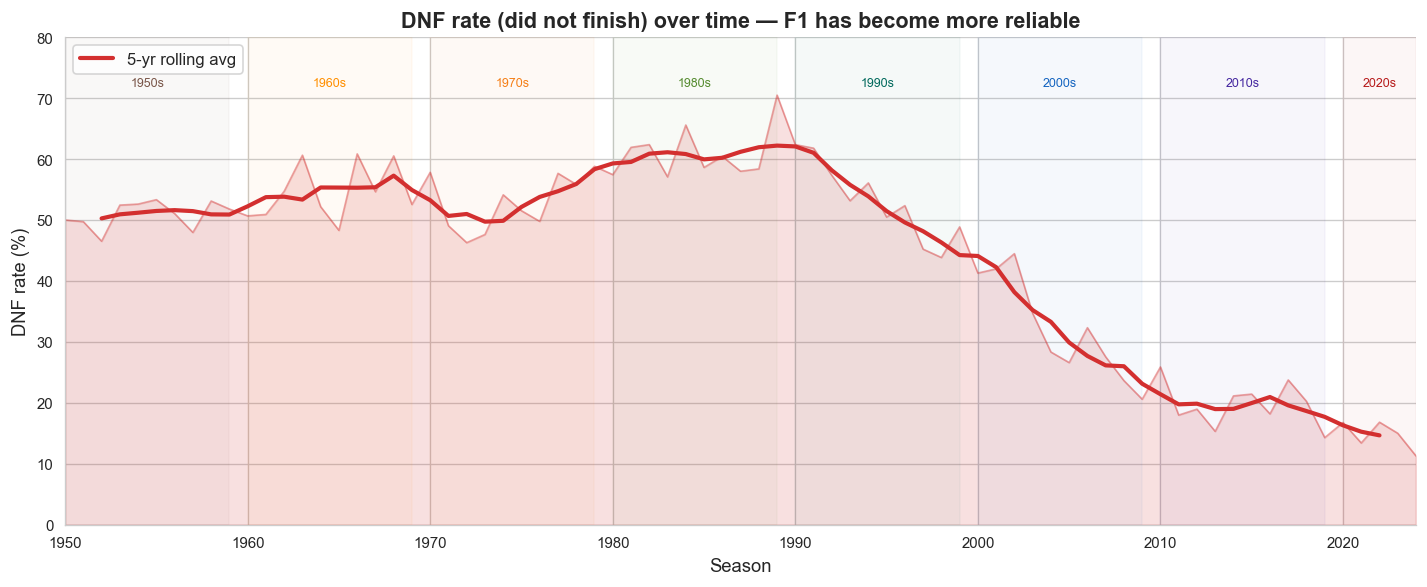

Mean DNF rate by decade:
  1950s: 50.9%
  1960s: 54.6%
  1970s: 52.8%
  1980s: 61.0%
  1990s: 53.1%
  2000s: 32.1%
  2010s: 19.7%
  2020s: 14.7%


In [ ]:
res_status = (
    results
    .merge(races[["raceId","year"]], on="raceId")
    .merge(status, on="statusId")
)
dnf_mask = (
    ~res_status["status"].isin(["Finished"]) &
    ~res_status["status"].str.startswith("+")
)
dnf_by_year  = res_status[dnf_mask].groupby("year").size()
total_by_year = res_status.groupby("year").size()
dnf_rate = (dnf_by_year / total_by_year * 100).reset_index()
dnf_rate.columns = ["year", "dnf_pct"]

dnf_rate["rolling"] = dnf_rate["dnf_pct"].rolling(5, center=True).mean()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(dnf_rate["year"], dnf_rate["dnf_pct"], alpha=0.15, color=RED)
ax.plot(dnf_rate["year"], dnf_rate["dnf_pct"], color=RED, alpha=0.4, linewidth=1)
ax.plot(dnf_rate["year"], dnf_rate["rolling"], color=RED, linewidth=2.5, label="5-yr rolling avg")

for era, (y1, y2) in ERA_BOUNDS.items():
    ax.axvspan(y1, y2, alpha=0.04, color=ERA_COLORS[era])
    ax.text((y1+y2)/2, 72, era.split()[0], ha="center", fontsize=7.5, color=ERA_COLORS[era])

ax.set_xlabel("Season"); ax.set_ylabel("DNF rate (%)")
ax.set_title("DNF rate (did not finish) over time — F1 has become more reliable",
             fontweight="bold")
ax.set_ylim(0, 80); ax.set_xlim(1950, 2024)
ax.legend()
plt.tight_layout()
plt.savefig(f"{SAVE}dnf_rate_over_time.png", bbox_inches="tight")
plt.show()

print("Mean DNF rate by decade:")
for d in range(1950, 2025, 10):
    mask = (dnf_rate["year"] >= d) & (dnf_rate["year"] <= d+9)
    print(f"  {d}s: {dnf_rate.loc[mask,'dnf_pct'].mean():.1f}%")


## Observation:
### For the first four decades, roughly half the field retired every race
From 1950s-1980s, the DNF rate stayed between 50-65%. In practical terms, this meant that in a race with 20 cars, around 10 of them would not see the chequered flag. Mechanical failures were the dominant cause: engines, gearboxes, and electrical systems of that era were simply not reliable enough to survive 60–70 laps of racing.

### 1989 is the worst year in the dataset (~70% DNF rate)
In 1989, F1 banned turbocharged engines and forced all teams to switch to naturally-aspirated engines mid-cycle. Many teams were unprepared, their car were unrealible, underpowered, and poorly developed. On top of that, the 1989 season had an unusually large number of entries, with many small teams that failed to pre-qualify. Those non-qualifications were counted as DNFs in the dataset, pushing the rate to ~70%, which is the highest single-season figure in 74 years of F1.

### The 2000s were the turning point, the rate dropped from ~50% to ~30% in one decade
The DNF rate fell from 50.5% in 1995 to just 26.6% in 2005, nearly cut in half in a decade. This improvement came from several reason: tighter FIA regulations standardised certain components and reduced experimental engineering failures, carbon-fibre construction became standard making cars both lighter and structurally stronger, and advance in electronics allowed teams to monitor and project engines in real time during a race.

### By 2024, not finishing a race becoming unusaul
In 2024, the rate dropped to 11.3%, the lowest in the dataset's entire history. The remaining DNFs are now dominated almost entirely by accidents and collisions (6.6% of races) rather than mechanical failures (3.4%). In 1980s, mechanical failures alone caused 26.7% of all starts to end early. The engineering problem of building a reliable F1 car has, for practical purposes, been solved. 

### The shift from mechanical to accident as the primary DNF cause tells the real story
In the 1980s the breakdown of DNF causes was: mechanical 26.7%, accident 11.3%. In the 2020s it has completely inverted: accident 6.6%, mechanical 3.4%. Accidents have not increased, they have actually decreased too, but they now represent the majority of retirements because mechanical failures have almost disappeared.

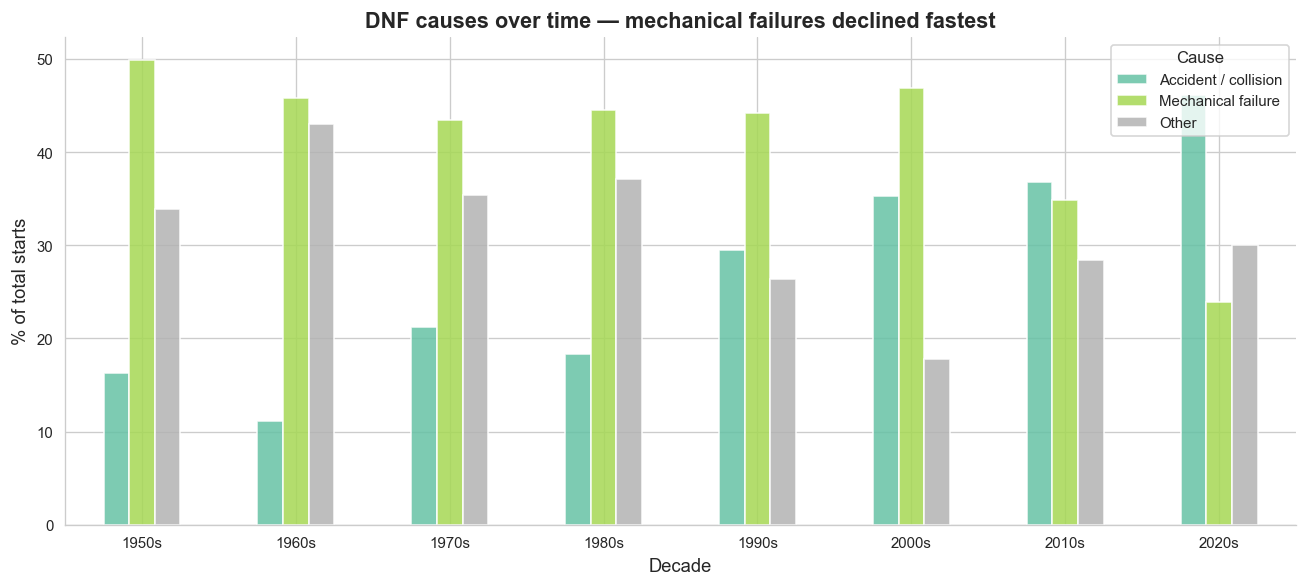

In [33]:
dnf_reasons = (
    res_status[dnf_mask]
    .copy()
)

mechanical = ["Engine","Gearbox","Transmission","Hydraulics","Electrical",
              "Clutch","Turbo","Suspension","Brakes","Differential",
              "Fuel system","Oil pressure","Cooling","Fuel pump","Tyre"]
accident_kws = ["Accident","Collision","Spun off","Damage","Debris"]

def categorize(s):
    if any(m.lower() in s.lower() for m in mechanical):
        return "Mechanical failure"
    if any(a.lower() in s.lower() for a in accident_kws):
        return "Accident / collision"
    return "Other"

dnf_reasons["category"] = dnf_reasons["status"].apply(categorize)
dnf_reasons["decade"] = (dnf_reasons["year"] // 10) * 10

dnf_cat_decade = (
    dnf_reasons.groupby(["decade","category"]).size()
    .unstack(fill_value=0)
    .div(dnf_reasons.groupby("decade").size(), axis=0) * 100
)

fig, ax = plt.subplots(figsize=(11, 5))
dnf_cat_decade.plot(kind="bar", ax=ax, colormap="Set2", alpha=0.85)
ax.set_xlabel("Decade"); ax.set_ylabel("% of total starts")
ax.set_title("DNF causes over time — mechanical failures declined fastest",
             fontweight="bold")
ax.set_xticklabels([f"{int(d)}s" for d in dnf_cat_decade.index], rotation=0)
ax.legend(title="Cause", fontsize=9)
plt.tight_layout()
plt.savefig(f"{SAVE}dnf_causes_over_time.png", bbox_inches="tight")
plt.show()


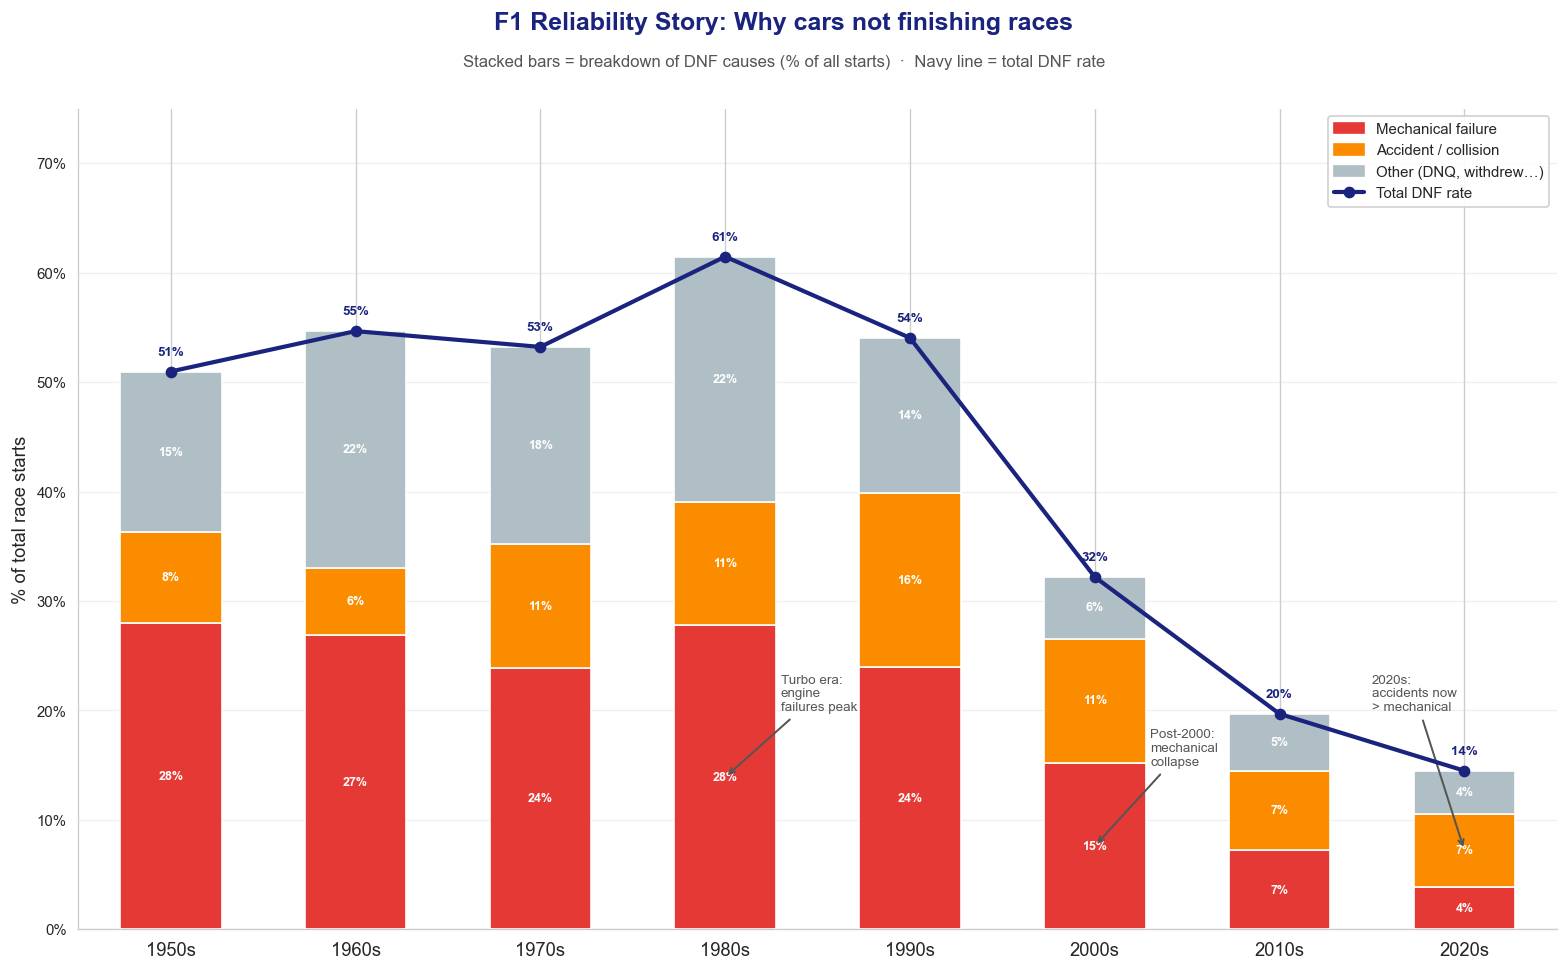

In [56]:
res = (results
       .merge(races[["raceId","year"]], on="raceId")
       .merge(status, on="statusId"))

dnf_mask = (~res["status"].isin(["Finished"]) &
            ~res["status"].str.startswith("+"))

mechanical = ["Engine","Gearbox","Transmission","Hydraulics","Electrical",
              "Clutch","Turbo","Suspension","Brakes","Fuel system", 
              "Oil pressure","Cooling","Fuel pump","Overheating", 
              "Water leak","Oil leak"]
accident_kws = ["Accident","Collision","Spun off","Damage","Debris"]

def cat(s):
    if any(m.lower() in s.lower() for m in mechanical): return "Mechanical"
    if any(a.lower() in s.lower() for a in accident_kws): return "Accident"
    return "Other"

res["cat"]    = res["status"].apply(cat)
res["decade"] = (res["year"] // 10) * 10

decades = list(range(1950, 2030, 10))
labels  = [f"{d}s" for d in decades]

total_by_dec = res.groupby("decade").size()
dnf_by_dec   = res[dnf_mask].groupby("decade").size()
mech_by_dec  = res[dnf_mask & (res["cat"]=="Mechanical")].groupby("decade").size()
acc_by_dec   = res[dnf_mask & (res["cat"]=="Accident")].groupby("decade").size()
oth_by_dec   = res[dnf_mask & (res["cat"]=="Other")].groupby("decade").size()

dnf_rate  = (dnf_by_dec  / total_by_dec * 100).reindex(decades, fill_value=0)
mech_rate = (mech_by_dec / total_by_dec * 100).reindex(decades, fill_value=0)
acc_rate  = (acc_by_dec  / total_by_dec * 100).reindex(decades, fill_value=0)
oth_rate  = (oth_by_dec  / total_by_dec * 100).reindex(decades, fill_value=0)

x = np.arange(len(decades))

C_MECH = "#E53935"
C_ACC  = "#FB8C00"
C_OTH  = "#B0BEC5"
C_LINE = "#1A237E"

fig = plt.figure(figsize=(14, 9))
fig.patch.set_facecolor("white")

fig.text(0.5, 0.97,
         "F1 Reliability Story: Why cars not finishing races",
         ha="center", va="top", fontsize=15, fontweight="bold", color="#1A237E")
fig.text(0.5, 0.93,
         "Stacked bars = breakdown of DNF causes (% of all starts)  ·  "
         "Navy line = total DNF rate",
         ha="center", va="top", fontsize=10, color="#555")

ax = fig.add_axes([0.08, 0.12, 0.88, 0.76])

ax.bar(x, mech_rate, width=0.55, color=C_MECH, label="Mechanical failure", zorder=3)
ax.bar(x, acc_rate,  width=0.55, color=C_ACC,  label="Accident / collision",
       bottom=mech_rate, zorder=3)
ax.bar(x, oth_rate,  width=0.55, color=C_OTH,  label="Other (DNQ, withdrew…)",
       bottom=mech_rate + acc_rate, zorder=3)

ax.plot(x, dnf_rate, color=C_LINE, linewidth=2.5, marker="o",
        markersize=6, zorder=5, label="Total DNF rate")

for i, d in enumerate(decades):
    m = mech_rate[d]; a = acc_rate[d]; o = oth_rate[d]
    if m > 2: ax.text(x[i], m/2,         f"{m:.0f}%", ha="center", va="center",
                      fontsize=7.5, fontweight="bold", color="white")
    if a > 2: ax.text(x[i], m + a/2,     f"{a:.0f}%", ha="center", va="center",
                      fontsize=7.5, fontweight="bold", color="white")
    if o > 2: ax.text(x[i], m + a + o/2, f"{o:.0f}%", ha="center", va="center",
                      fontsize=7.5, fontweight="bold", color="white")
    ax.text(x[i], dnf_rate[d] + 1.5, f"{dnf_rate[d]:.0f}%",
            ha="center", fontsize=8, color=C_LINE, fontweight="bold")

ax.annotate("Turbo era:\nengine\nfailures peak",
            xy=(x[3], mech_rate[1980]/2),
            xytext=(x[3]+0.3, 20),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
            fontsize=8, color="#555", ha="left")

ax.annotate("Post-2000:\nmechanical\ncollapse",
            xy=(x[5], mech_rate[2000]/2),
            xytext=(x[5]+0.3, 15),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
            fontsize=8, color="#555", ha="left")

ax.annotate("2020s:\naccidents now\n> mechanical",
            xy=(x[7], mech_rate[2020]+acc_rate[2020]/2),
            xytext=(x[7]-0.5, 20),
            arrowprops=dict(arrowstyle="->", color="#555", lw=1.2),
            fontsize=8, color="#555", ha="left")

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel("% of total race starts", fontsize=11)
ax.set_ylim(0, 75)
ax.set_xlim(-0.5, len(decades)-0.5)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{int(v)}%"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", alpha=0.3, zorder=0)

handles = [
    mpatches.Patch(color=C_MECH, label="Mechanical failure"),
    mpatches.Patch(color=C_ACC,  label="Accident / collision"),
    mpatches.Patch(color=C_OTH,  label="Other (DNQ, withdrew…)"),
    plt.Line2D([0],[0], color=C_LINE, linewidth=2.5,
               marker="o", markersize=6, label="Total DNF rate"),
]
ax.legend(handles=handles, loc="upper right", fontsize=9,
          framealpha=0.9, edgecolor="#ccc")

plt.savefig("visualization/dnf_combined.png", dpi=130,
            bbox_inches="tight", facecolor="white")
plt.show()

## Observation:
The stacked bars and the blue navy line measure the same thing(percentage of total race starts), so they can be read together directly. Each bar shows what share of all starts in that decade ended without finishing, broken down by cause. The navy line is simply the total height of each bar, making it easy to see both the overall trend and what is driving it at the same time.

### Total DNF rate fell from 61% to 14%
The navy line peaked in the 1980s at 61% and has fallen every decade, reaching 14% in the 2020s. The red bar (mechanical failure) tells the whole story, it stayed flat at 24–28% of all races from the 1950s through the 1990s, then dropped sharply to 15% in the 2000s, 7% in the 2010s, and just 4% in the 2020s. The orange bar (accidents) and grey bar (other) barely changed in absolute terms, the line fell because red almost disappeared.

### The 1980s peak at 61% was caused by the Turbo era, not just poor reliability
The 1980s red bar (28%) matches the 1950s level, mechanical failures were no worse than before. What pushed the total to 61% was the grey "Other" bar jumping to 22%, the highest of any decade. This came from two Turbo-era effects: qualifying engines that were too fragile to race (counted under "Other" categories like "Withdrew" or "Did not start"), and a lot of team entries including many small under-resourced teams that regularly failed to pre-qualify.

### The 2020s is the first decade where accidents > mechanical failures
In the 2020s the orange bar (7%) is taller than the red bar (4%) for the first time in history. This is not because accident have increased, 7% is actually below the historical accident average, but because mechanical failures have declined so far that accidents are now the dominant remaining cause of retirement. The chart makes this inversion visually obvious in a way that two separate charts cannot.